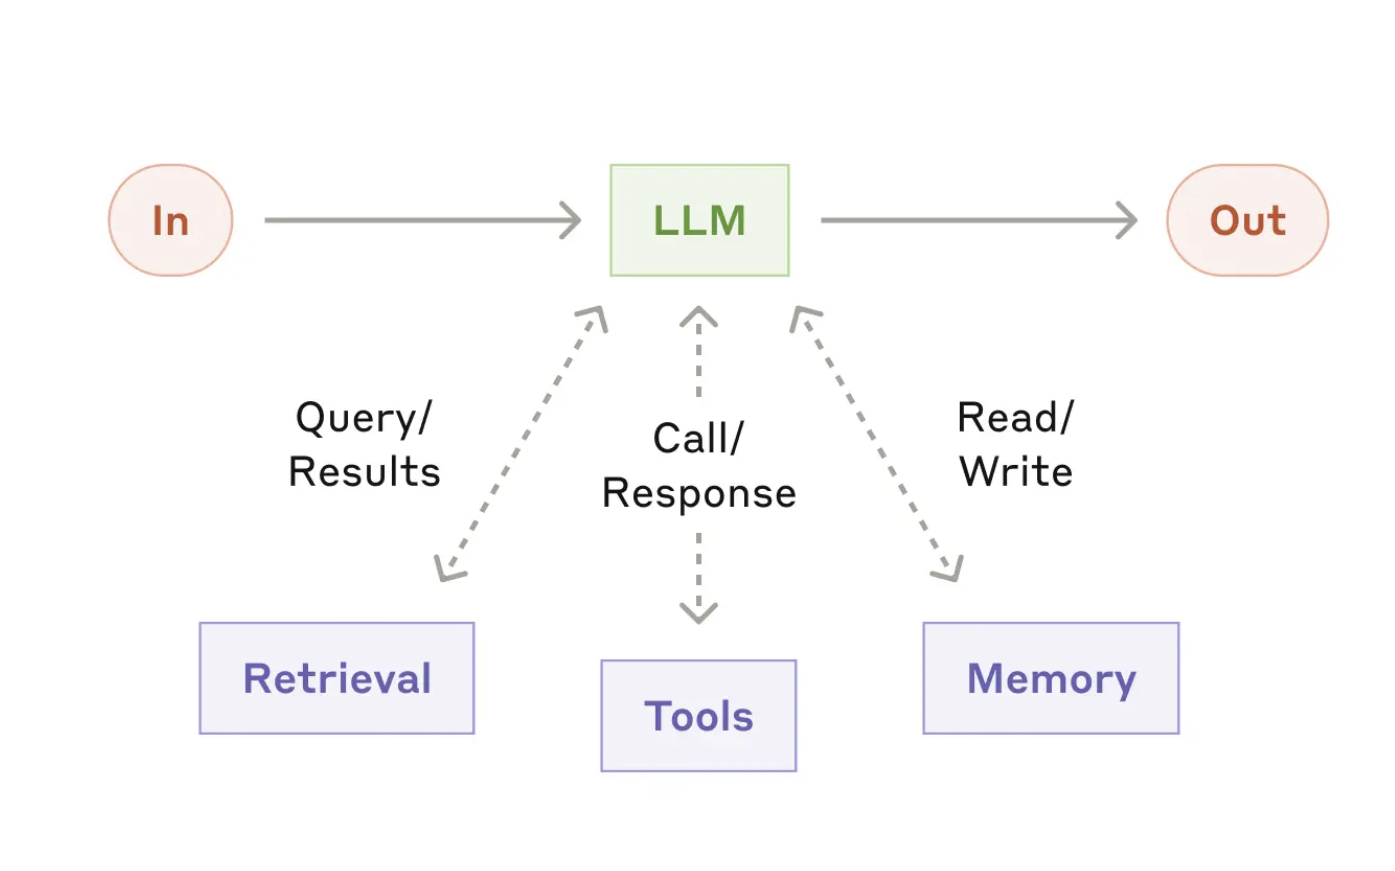

<a href="https://langchain-ai.github.io/langgraph/tutorials/workflows/">Source</a>

# 0.0. Configure

In [1]:
from dotenv import load_dotenv

In [65]:
load_dotenv()

True

# 1.0. Imports

In [29]:
from pydantic import BaseModel, Field
from typing import Type

from langchain_openai import ChatOpenAI
from langchain.tools import BaseTool

# 2.0. Hands-On

## 2.1. Define output format

In [6]:
llm = ChatOpenAI(model="gpt-4o")

In [18]:
class SearchQuery1(BaseModel):
    search_query: str = Field(None, description="Query that is optimized web search.")
    justification: str = Field(None, justification="Why this query is relevant to the user's request.")

class SearchQuery2(BaseModel):
    search_query: str = Field(None, description="Query that is optimized web search.")
    justification: str = Field(..., justification="Why this query is relevant to the user's request.")

### 2.1.1. `SearchQuery1`

In [19]:
structured_llm = llm.with_structured_output(SearchQuery1)

In [20]:
output = structured_llm.invoke("How does Calcium CT score relate to high cholesterol?")

In [21]:
output.search_query

'Calcium CT score relation to high cholesterol'

In [22]:
output.justification

### 2.1.2. `SearchQuery2`

In [ ]:
structured_llm = llm.with_structured_output(SearchQuery2)

In [23]:
output = structured_llm.invoke("How does Calcium CT score relate to high cholesterol?")

In [24]:
output.search_query

'Calcium CT score relation to high cholesterol'

In [25]:
output.justification

'To provide an accurate and updated explanation on the correlation between calcium CT scores and high cholesterol.'

## 2.2. Tool use

In [26]:
llm = ChatOpenAI(model="gpt-4o-mini")

In [61]:
class CalculatorInput(BaseModel):
    first_number: float = Field(..., description="The first number to be used in the calculation.")
    second_number: float = Field(..., description="The second number to be used in the calculation.")

class SumTool(BaseTool):
    name = "Sum-Tool"
    description = "This tool calculates the sum of two numbers."
    args_schema: Type[BaseModel] = CalculatorInput
    return_direct: bool = True

    def _run(
        self,
        first_number: float,
        second_number: float,
    ) -> float:
        return first_number + second_number
    
class SubTool(BaseTool):
    name = "Sub-Tool"
    description = "This tool calculates the subtraction of two numbers."
    args_schema: Type[BaseModel] = CalculatorInput
    return_direct: bool = True

    def _run(
        self,
        first_number: float,
        second_number: float
    ) -> float:
        return first_number - second_number
    
class MulTool(BaseTool):
    name = "Mul-Tool"
    description = "This tool calculates the multiplication of two numbers."
    args_schema: Type[BaseModel] = CalculatorInput
    return_direct: bool = True

    def _run(
        self,
        first_number: float,
        second_number: float
    ) -> float:
        return first_number * second_number
    
class DivTool(BaseTool):
    name = "Div-Tool"
    description = "This tool calculates the division of two numbers."
    args_schema: Type[BaseModel] = CalculatorInput
    return_direct: bool = True

    def _run(
        self,
        first_number: float,
        second_number: float
    ) -> float:
        return first_number / second_number
    
class CalculatorOutput(BaseModel):
    result: float = Field(..., description="The result of the calculation.")
    operation: str = Field(..., description="The operation that was performed [sum, sub, mul, div].")

In [62]:
sum_tool = SumTool()
sub_tool = SubTool()
mul_tool = MulTool()
div_tool = DivTool()

llm_with_tools = llm.bind_tools([sum_tool, sub_tool, mul_tool, div_tool])
llm_with_tools = llm_with_tools.with_structured_output(CalculatorOutput)

### Sum example

In [63]:
output = llm_with_tools.invoke("What is the sum of 5 and 3?")

In [49]:
output.result

8.0

In [50]:
output.operation

'sum'

### Subtraction example

In [51]:
output = llm_with_tools.invoke("What is 5 minus 3?")

In [52]:
output.result

2.0

In [53]:
output.operation

'sub'

### Multiplication example

In [54]:
output = llm_with_tools.invoke("What is 5 times 3?")

In [55]:
output.result

15.0

In [56]:
output.operation

'mul'

### Division example

In [57]:
output = llm_with_tools.invoke("What is 5 divided by 3?")

In [58]:
output.result

1.6666666666666667

In [59]:
output.operation

'div'